In [ ]:
%cd ../..

In [2]:
import os
from data.utils_strokerehab import PrimitiveLabelUtils, DataPaths
from lmms_eval.tasks.strokerehab.utils_primitives import load_strokerehab_primitives_dataset

In [3]:
# Convert prims and times into three binary sequences
# 1. motion: reach, transport, reposition
# 2. contact: stabilize, transport
# reposition = no contact in "immediate" future
# contact = contact in "immediate" future

def get_prims_motion_contact(path_l):
    full_path = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    prims, times = PrimitiveLabelUtils.convert_labels_to_prims_times(full_path)

    motion, contact = [], []

    for prim in prims:
        motion.append(prim in ['reach', 'transport', 'reposition'])
        contact.append(prim in ['stabilize', 'transport'])
    return prims, motion, contact, times


In [4]:
def get_num_prims(path_l):
    full_path = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    prims, times = PrimitiveLabelUtils.convert_labels_to_prims_times(full_path)
    return len(prims)

In [5]:
from lmms_eval.tasks.strokerehab.utils_primitives import _get_primitives_score


def motion_contact_flags_to_primitives(motion_flags, contact_flags, times, future_window=5.0):
    primitives = []
    start_times = times[:-1]  # length n
    n = len(start_times)

    for i in range(n):
        t0 = start_times[i]
        m = motion_flags[i]
        c = contact_flags[i]

        if m and not c:
            # scan ahead up to future_window
            reach = False
            j = i + 1
            while j < n and (start_times[j] - t0) <= future_window:
                if contact_flags[j]:
                    reach = True
                    break
                j += 1
            prim = "reach" if reach else "reposition"

        elif m and c:
            prim = "transport"

        elif not m and c:
            prim = "stabilize"

        else:  # not m and not c
            prim = "idle"

        primitives.append(prim)
    
    return primitives

import numpy as np
def evaluate_window(prims_motion_contact, future_window=5.0):
    scores = []

    for gt_prims, motion_flags, contact_flags, times in prims_motion_contact:
        pred_prims = motion_contact_flags_to_primitives(
            motion_flags, contact_flags, times, future_window=future_window
        )
        score_dict = _get_primitives_score(pred_prims, gt_prims)
        action_error_rate = score_dict['action_error_rate']
        scores.append(action_error_rate)
    return np.mean(action_error_rate)

In [6]:
def get_num_reach_repositions(path_l):
    full_path = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    prims, times = PrimitiveLabelUtils.convert_labels_to_prims_times(full_path)
    count = sum(1 for prim in prims if prim in ['reach', 'reposition'])
    return count

206


7381
3068
0.0


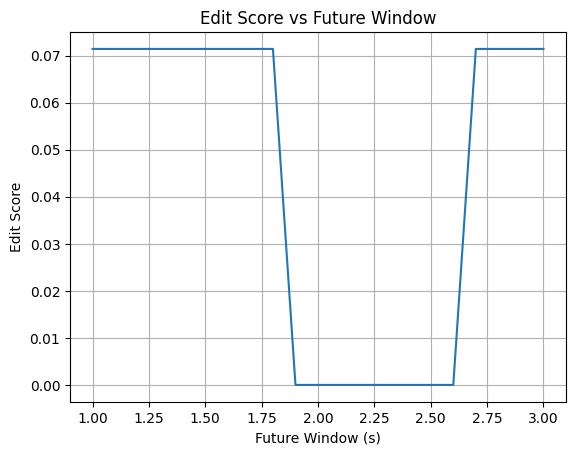

In [7]:

ds = load_strokerehab_primitives_dataset(patients='C00015,C00020')
print(len(ds['test']))
print(ds['test'].to_pandas()['path_l'].apply(get_num_prims).sum())
print(ds['test'].to_pandas()['path_l'].apply(get_num_reach_repositions).sum())
prims_motion_contact = [get_prims_motion_contact(path_l) for path_l in ds['test']['path_l']]
future_window = np.linspace(1.0, 3.0, 21)
scores = [evaluate_window(prims_motion_contact, future_window=f) for f in future_window]
print(min(scores))
import matplotlib.pyplot as plt
plt.plot(future_window, scores)
plt.xlabel('Future Window (s)')
plt.ylabel('Edit Score')
plt.title('Edit Score vs Future Window')
plt.grid()
plt.show()

In [8]:
len(scores)

21

50
1770
566
0.05128205128205128


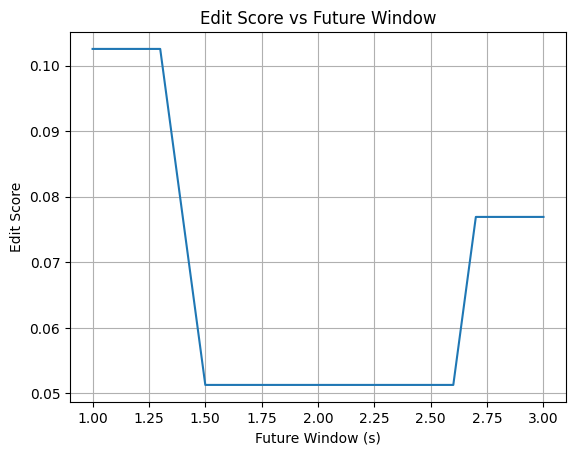

In [53]:
ds = load_strokerehab_primitives_dataset(filter_for_subsampled_testset=True)
print(len(ds['test']))
print(ds['test'].to_pandas()['path_l'].apply(get_num_prims).sum())
print(ds['test'].to_pandas()['path_l'].apply(get_num_reach_repositions).sum())

prims_motion_contact = [get_prims_motion_contact(path_l) for path_l in ds['test']['path_l']]
future_window = np.linspace(1.0, 3.0, 21)
scores = [evaluate_window(prims_motion_contact, future_window=f) for f in future_window]
print(min(scores))
import matplotlib.pyplot as plt
plt.plot(future_window, scores)
plt.xlabel('Future Window (s)')
plt.ylabel('Edit Score')
plt.title('Edit Score vs Future Window')
plt.grid()
plt.show()

In [36]:
# We should use 2.0 seconds as the future window for the primitives evaluation.